In [1]:
# ======================================================================================
# CELL 1 — Install, imports, Drive, GPU policy
# ======================================================================================
!pip install -q scikit-learn matplotlib seaborn opencv-python-headless lime shap scikit-image

import os, math, json, time, random, warnings, re, gc, shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, regularizers, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score, matthews_corrcoef,
    balanced_accuracy_score, accuracy_score, precision_score, recall_score
)

from google.colab import drive
drive.mount("/content/drive")

# ResNet50 is stable in float32 for gradient/XAI compatibility.
tf.keras.mixed_precision.set_global_policy("float32")
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# GPU memory growth.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("=" * 80)
print("TensorFlow :", tf.__version__)
print("GPU        :", gpus)
print("Policy     :", tf.keras.mixed_precision.global_policy().name)
print("=" * 80)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive
TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Policy     : float32


In [2]:
# ======================================================================================
# CELL 2 — Configuration: edit only this cell if needed
# ======================================================================================
JPEG_BASE  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/jpeg")
CSV_DIR    = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/csv")
SPLIT_DIR  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split")

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

TRAIN_MANIFEST = SPLIT_DIR / "train_manifest.csv"
VAL_MANIFEST   = SPLIT_DIR / "val_manifest.csv"
TEST_MANIFEST  = SPLIT_DIR / "test_manifest.csv"
FULL_MANIFEST  = SPLIT_DIR / "full_manifest.csv"

MODEL_NAME = "ResNet50_ULTRA_V6_PATIENT_SAFE"
SAVE_DIR   = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = Path("/content/resnet50_patient_safe_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Critical anti-regression guardrails. Adjust only if your intentional split is smaller.
EXPECTED_MIN_TRAIN = 1500
EXPECTED_MIN_VAL   = 300
EXPECTED_MIN_TEST  = 300

# Image settings. 256 usually improves lesion detail over 224 while staying T4-safe.
IMG_SIZE    = 256
RESIZE_SIZE = 288
CHANNELS    = 3
BATCH_SIZE  = 24      # if OOM, use 16; if A100/L4, try 32.

# Training schedule.
PHASE1_EPOCHS = 18    # frozen backbone, head calibration
PHASE2_EPOCHS = 45    # conv5_x fine-tune
PHASE3_EPOCHS = 28    # conv4_x + conv5_x polish

# Learning rates. ResNet50 accepts slightly higher LR than VGG19, but keep fine-tuning conservative.
PHASE1_LR = 6e-4
PHASE2_LR = 2.0e-5
PHASE3_LR = 5.0e-6
MIN_LR    = 1e-8
WARMUP_FRAC = 0.08

# Regularization.
WEIGHT_DECAY = 6e-5
L2_REG       = 1e-5
DROPOUT_RATE = 0.36
CLIPNORM     = 1.0

# Loss strategy. Weighted BCE is the default; focal is available if recall collapses.
USE_FOCAL_LOSS  = False
FOCAL_GAMMA     = 2.0
FOCAL_ALPHA      = None    # computed after reading split
LABEL_SMOOTH    = 0.00

# Conservative augmentation.
USE_CLAHE       = True
CLAHE_CLIP      = 2.2
CLAHE_GRID      = (8, 8)

CUTOUT_PROB      = 0.06
CUTOUT_SIZE      = 32
BRIGHTNESS_DELTA = 8.0
CONTRAST_LO      = 0.92
CONTRAST_HI      = 1.08
NOISE_STD_RAW    = 1.00
ROT90_PROB       = 0.25

# Optional batch mixing for Phase 1 only. OFF by default for medical-lesion stability.
USE_BATCH_MIXING = False
MIXUP_ALPHA      = 0.20
CUTMIX_ALPHA     = 1.00
MIXUP_PROB       = 0.06
CUTMIX_PROB      = 0.03

# Snapshot / TTA.
TOP_K_SNAPSHOTS = 4
TTA_STEPS       = 8

# Reproducibility.
RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("=" * 80)
print(f"Model       : {MODEL_NAME}")
print(f"Input       : resize {RESIZE_SIZE} -> crop {IMG_SIZE} x {IMG_SIZE} x {CHANNELS}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : P1={PHASE1_EPOCHS}, P2={PHASE2_EPOCHS}, P3={PHASE3_EPOCHS}")
print(f"LRs         : P1={PHASE1_LR:g}, P2={PHASE2_LR:g}, P3={PHASE3_LR:g}")
print(f"Loss        : {'Focal BCE' if USE_FOCAL_LOSS else 'Weighted BCE'}")
print(f"Augment     : CLAHE={USE_CLAHE}, batch_mix={USE_BATCH_MIXING}, TTA={TTA_STEPS}")
print(f"Save dir    : {SAVE_DIR}")
print("=" * 80)


Model       : ResNet50_ULTRA_V6_PATIENT_SAFE
Input       : resize 288 -> crop 256 x 256 x 3
Batch size  : 24
Epochs      : P1=18, P2=45, P3=28
LRs         : P1=0.0006, P2=2e-05, P3=5e-06
Loss        : Weighted BCE
Augment     : CLAHE=True, batch_mix=False, TTA=8
Save dir    : /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6


In [3]:
# ======================================================================================
# CELL 3 — PATIENT-SAFE dataset collection: rebuild split by patient ID
# ======================================================================================
# Why this cell exists:
# Your existing cropped_split folders have correct image counts, but the same patient IDs
# appear across train/val/test. That is patient leakage. This cell fixes it by pooling all
# cropped images, then creating a new 70/15/15 split where each patient appears in exactly
# one split only.

from sklearn.model_selection import train_test_split

IMG_EXTS = (".jpg", ".jpeg", ".png")
LABEL2INT = {
    "benign": 0, "BENIGN": 0, "0": 0, 0: 0,
    "malignant": 1, "MALIGNANT": 1, "1": 1, 1: 1,
}

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    assert p.exists(), f"Missing split directory: {p}"

def extract_patient_id(path_like):
    """Best-effort patient/case ID extraction.

    For your current files this should capture IDs like 1-000, 1-001, etc.
    It also handles common CBIS-DDSM names like P_00001 / P-00001.
    """
    s = str(path_like)
    stem = Path(s).stem

    patterns = [
        r"(?i)([12][-_]\d{3,5})",          # observed examples: 1-000, 2-123
        r"(?i)(P[_-]?\d{3,6})",            # CBIS-style patient IDs
        r"(?i)(patient[_-]?\d{3,6})",
        r"(?i)(Calc[-_]Training[_-]P[_-]?\d+)",
        r"(?i)(Mass[-_]Training[_-]P[_-]?\d+)",
        r"(?i)(Calc[-_]Test[_-]P[_-]?\d+)",
        r"(?i)(Mass[-_]Test[_-]P[_-]?\d+)",
    ]
    for pat in patterns:
        m = re.search(pat, s)
        if m:
            return m.group(1).upper().replace("_", "-")

    # Final fallback: use the leading case token before the first underscore.
    # This matches your current output examples such as 1-000.
    return stem.split("_")[0].upper().replace("_", "-")

def collect_from_split_folder(split_name, split_dir):
    rows = []
    for label_name, label_val in [("malignant", 1), ("benign", 0)]:
        folder = split_dir / label_name
        if not folder.exists():
            continue
        for f in sorted(folder.iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                rows.append({
                    "path": str(f),
                    "label": int(label_val),
                    "patient_id": extract_patient_id(f),
                    "original_split": split_name,
                    "source": "folder_pool_patient_resplit",
                })
    return pd.DataFrame(rows)

def resolve_manifest_path(p, split):
    s = str(p)
    cand = Path(s)
    if cand.is_absolute() and cand.exists():
        return str(cand)
    checks = [
        SPLIT_DIR / s,
        SPLIT_DIR / split / s,
        SPLIT_DIR / split / "malignant" / Path(s).name,
        SPLIT_DIR / split / "benign" / Path(s).name,
        JPEG_BASE / s,
        JPEG_BASE / Path(s).name,
    ]
    for c in checks:
        if c.exists():
            return str(c)
    return None

def collect_from_manifest(manifest_csv, split):
    """Fallback only, used if folders are empty."""
    if not manifest_csv.exists():
        return pd.DataFrame(columns=["path", "label", "patient_id", "original_split", "source"])
    df = pd.read_csv(manifest_csv)
    path_col = next((c for c in ["path", "filepath", "file_path", "image", "image_path", "filename", "file", "new_filepath"] if c in df.columns), None)
    label_col = next((c for c in ["label", "class", "target", "pathology", "y", "label_str"] if c in df.columns), None)
    if path_col is None or label_col is None:
        return pd.DataFrame(columns=["path", "label", "patient_id", "original_split", "source"])
    pid_col = next((c for c in ["patient_id", "patient", "case_id"] if c in df.columns), None)

    rows = []
    for _, row in df.iterrows():
        p = resolve_manifest_path(row[path_col], split)
        if p is None:
            continue
        lab = row[label_col]
        if isinstance(lab, str):
            lab = lab.strip().lower()
        if lab not in LABEL2INT:
            continue
        rows.append({
            "path": p,
            "label": int(LABEL2INT[lab]),
            "patient_id": str(row[pid_col]).upper().replace("_", "-") if pid_col is not None else extract_patient_id(p),
            "original_split": split,
            "source": "manifest_pool_patient_resplit",
        })
    return pd.DataFrame(rows)

def collect_all_images_for_patient_resplit():
    folder_parts = [
        collect_from_split_folder("train", TRAIN_DIR),
        collect_from_split_folder("val", VAL_DIR),
        collect_from_split_folder("test", TEST_DIR),
    ]
    folder_df = pd.concat(folder_parts, ignore_index=True)
    folder_df = folder_df.drop_duplicates(subset=["path"]).reset_index(drop=True)

    manifest_parts = [
        collect_from_manifest(TRAIN_MANIFEST, "train"),
        collect_from_manifest(VAL_MANIFEST, "val"),
        collect_from_manifest(TEST_MANIFEST, "test"),
    ]
    manifest_df = pd.concat(manifest_parts, ignore_index=True)
    manifest_df = manifest_df.drop_duplicates(subset=["path"]).reset_index(drop=True)

    print("\nSOURCE AUDIT BEFORE PATIENT RE-SPLIT")
    print(f"  folder pooled images   : {len(folder_df):,}")
    print(f"  manifest pooled images : {len(manifest_df):,}")

    if len(folder_df) > 0:
        all_df = folder_df.copy()
        chosen = "folder-pool"
    else:
        all_df = manifest_df.copy()
        chosen = "manifest-pool-fallback"

    all_df = all_df.drop_duplicates(subset=["path"]).reset_index(drop=True)
    all_df["patient_id"] = all_df["patient_id"].astype(str).str.upper().str.replace("_", "-", regex=False)

    expected_total = EXPECTED_MIN_TRAIN + EXPECTED_MIN_VAL + EXPECTED_MIN_TEST
    if len(all_df) < expected_total:
        raise RuntimeError(
            f"Only {len(all_df):,} total images found from {chosen}. Expected at least {expected_total:,}. "
            "Check cropped_split folders/manifests before training."
        )

    print(f"  SELECTED pooled source : {len(all_df):,} images ({chosen})")
    print(f"  unique patients/cases  : {all_df['patient_id'].nunique():,}")
    return all_df

all_df = collect_all_images_for_patient_resplit()

# Patient-level stratification target:
# A patient/case group is marked malignant-positive if it contains at least one malignant image.
# This keeps class balance reasonable while guaranteeing no patient leakage.
patient_summary = (
    all_df.groupby("patient_id")
    .agg(
        n_images=("path", "count"),
        n_malignant=("label", "sum"),
        n_benign=("label", lambda x: int((x == 0).sum())),
    )
    .reset_index()
)
patient_summary["group_label"] = (patient_summary["n_malignant"] > 0).astype(int)

print("\nPATIENT GROUP SUMMARY")
print(f"  total groups       : {len(patient_summary):,}")
print(f"  malignant groups   : {int(patient_summary['group_label'].sum()):,}")
print(f"  benign-only groups : {int((patient_summary['group_label'] == 0).sum()):,}")
print(f"  images per group   : min={patient_summary['n_images'].min()}, median={patient_summary['n_images'].median():.1f}, max={patient_summary['n_images'].max()}")

def can_stratify(y):
    vc = pd.Series(y).value_counts()
    return len(vc) >= 2 and vc.min() >= 2

def safe_train_test_split(ids, labels, test_size, seed, name):
    stratify = labels if can_stratify(labels) else None
    if stratify is None:
        print(f"⚠️ {name}: stratified split not possible; using unstratified patient split.")
    return train_test_split(
        ids,
        test_size=test_size,
        random_state=seed,
        shuffle=True,
        stratify=stratify,
    )

patient_ids = patient_summary["patient_id"].tolist()
group_labels = patient_summary["group_label"].tolist()

train_pids, temp_pids = safe_train_test_split(
    patient_ids,
    group_labels,
    test_size=0.30,
    seed=RANDOM_SEED,
    name="train/temp",
)

temp_summary = patient_summary[patient_summary["patient_id"].isin(temp_pids)].copy()
val_pids, test_pids = safe_train_test_split(
    temp_summary["patient_id"].tolist(),
    temp_summary["group_label"].tolist(),
    test_size=0.50,
    seed=RANDOM_SEED + 1,
    name="val/test",
)

train_pids = set(train_pids)
val_pids = set(val_pids)
test_pids = set(test_pids)

assert train_pids.isdisjoint(val_pids)
assert train_pids.isdisjoint(test_pids)
assert val_pids.isdisjoint(test_pids)

train_df = all_df[all_df["patient_id"].isin(train_pids)].copy().reset_index(drop=True)
val_df   = all_df[all_df["patient_id"].isin(val_pids)].copy().reset_index(drop=True)
test_df  = all_df[all_df["patient_id"].isin(test_pids)].copy().reset_index(drop=True)

def split_stats(name, df):
    m = int((df["label"] == 1).sum())
    b = int((df["label"] == 0).sum())
    t = len(df)
    patients = df["patient_id"].nunique()
    return name, m, b, t, patients, 100.0 * m / max(t, 1)

print("\nPATIENT-SAFE SPLIT DISTRIBUTION")
print(f"{'Split':<8} {'Malignant':>10} {'Benign':>8} {'Total':>7} {'Patients':>9}  Mal%")
print("-" * 62)
for row in [split_stats("train", train_df), split_stats("val", val_df), split_stats("test", test_df)]:
    name, m, b, t, patients, pct = row
    print(f"{name:<8} {m:>10,} {b:>8,} {t:>7,} {patients:>9,}  {pct:5.1f}%")

# Hard count checks after patient-level split.
# These prevent accidental tiny splits while allowing natural patient-level count variation.
if len(train_df) < EXPECTED_MIN_TRAIN:
    raise RuntimeError(f"Patient-safe train split too small: {len(train_df):,} < {EXPECTED_MIN_TRAIN:,}")
if len(val_df) < EXPECTED_MIN_VAL:
    raise RuntimeError(f"Patient-safe val split too small: {len(val_df):,} < {EXPECTED_MIN_VAL:,}")
if len(test_df) < EXPECTED_MIN_TEST:
    raise RuntimeError(f"Patient-safe test split too small: {len(test_df):,} < {EXPECTED_MIN_TEST:,}")

# Class weights and focal alpha from the new leakage-free training split.
n_mal = int((train_df["label"] == 1).sum())
n_ben = int((train_df["label"] == 0).sum())
n_tot = n_mal + n_ben
assert n_mal > 0 and n_ben > 0, "Both classes must exist in train split."

CLASS_WEIGHTS = {
    0: n_tot / (2.0 * n_ben),
    1: n_tot / (2.0 * n_mal),
}
FOCAL_ALPHA = float(np.clip(n_ben / n_tot, 0.45, 0.65))
print(f"\nClass weights -> benign={CLASS_WEIGHTS[0]:.4f}, malignant={CLASS_WEIGHTS[1]:.4f}")
print(f"Focal alpha   -> positive/malignant alpha={FOCAL_ALPHA:.4f}")

# Leakage audits. Patient overlap is now fatal, not just a warning.
def patient_overlap(a_name, a_df, b_name, b_df):
    inter = set(a_df["patient_id"]) & set(b_df["patient_id"])
    if inter:
        raise RuntimeError(f"PATIENT LEAKAGE {a_name} ↔ {b_name}: {len(inter)} IDs. Example: {list(sorted(inter))[:8]}")
    print(f"✓ No patient overlap detected: {a_name} ↔ {b_name}")

def path_overlap(a_name, a_df, b_name, b_df):
    inter = set(a_df["path"]) & set(b_df["path"])
    if inter:
        raise RuntimeError(f"Exact image path leakage {a_name} ↔ {b_name}: {len(inter)} files")
    print(f"✓ No exact path overlap: {a_name} ↔ {b_name}")

print("\nLEAKAGE AUDIT — PATIENT-SAFE MODE")
path_overlap("train", train_df, "val", val_df)
path_overlap("train", train_df, "test", test_df)
path_overlap("val", val_df, "test", test_df)
patient_overlap("train", train_df, "val", val_df)
patient_overlap("train", train_df, "test", test_df)
patient_overlap("val", val_df, "test", test_df)

# Persist split inventory and config.
train_df.to_csv(SAVE_DIR / "train_inventory_patient_safe.csv", index=False)
val_df.to_csv(SAVE_DIR / "val_inventory_patient_safe.csv", index=False)
test_df.to_csv(SAVE_DIR / "test_inventory_patient_safe.csv", index=False)
all_df.to_csv(SAVE_DIR / "all_inventory_before_patient_resplit.csv", index=False)
patient_summary.to_csv(SAVE_DIR / "patient_group_summary.csv", index=False)

# Also save generic names so downstream cells and external analysis stay simple.
train_df.to_csv(SAVE_DIR / "train_inventory.csv", index=False)
val_df.to_csv(SAVE_DIR / "val_inventory.csv", index=False)
test_df.to_csv(SAVE_DIR / "test_inventory.csv", index=False)

config = {
    "MODEL_NAME": MODEL_NAME,
    "SPLIT_MODE": "patient_level_70_15_15_from_pooled_cropped_split",
    "SPLIT_DIR": str(SPLIT_DIR),
    "SAVE_DIR": str(SAVE_DIR),
    "IMG_SIZE": IMG_SIZE,
    "RESIZE_SIZE": RESIZE_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "PHASE1_EPOCHS": PHASE1_EPOCHS,
    "PHASE2_EPOCHS": PHASE2_EPOCHS,
    "PHASE3_EPOCHS": PHASE3_EPOCHS,
    "USE_FOCAL_LOSS": USE_FOCAL_LOSS,
    "USE_BATCH_MIXING": USE_BATCH_MIXING,
    "CLASS_WEIGHTS": CLASS_WEIGHTS,
    "FOCAL_ALPHA": FOCAL_ALPHA,
    "total_count": len(all_df),
    "total_patients": int(all_df["patient_id"].nunique()),
    "train_count": len(train_df),
    "val_count": len(val_df),
    "test_count": len(test_df),
    "train_patients": int(train_df["patient_id"].nunique()),
    "val_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(test_df["patient_id"].nunique()),
}
with open(SAVE_DIR / "run_config.json", "w") as f:
    json.dump(config, f, indent=2)



SOURCE AUDIT BEFORE PATIENT RE-SPLIT
  folder pooled images   : 3,549
  manifest pooled images : 1,157
  SELECTED pooled source : 3,549 images (folder-pool)
  unique patients/cases  : 571

PATIENT GROUP SUMMARY
  total groups       : 571
  malignant groups   : 488
  benign-only groups : 83
  images per group   : min=1, median=7.0, max=14

PATIENT-SAFE SPLIT DISTRIBUTION
Split     Malignant   Benign   Total  Patients  Mal%
--------------------------------------------------------------
train         1,032    1,485   2,517       399   41.0%
val             198      305     503        86   39.4%
test            220      309     529        86   41.6%

Class weights -> benign=0.8475, malignant=1.2195
Focal alpha   -> positive/malignant alpha=0.5900

LEAKAGE AUDIT — PATIENT-SAFE MODE
✓ No exact path overlap: train ↔ val
✓ No exact path overlap: train ↔ test
✓ No exact path overlap: val ↔ test
✓ No patient overlap detected: train ↔ val
✓ No patient overlap detected: train ↔ test
✓ No patient 

In [4]:
# ======================================================================================
# CELL 4 — Preprocessing, augmentation, tf.data pipelines
# ======================================================================================
AUTO = tf.data.AUTOTUNE

def clahe_np(img_uint8):
    """CLAHE on LAB L-channel. Input/output RGB uint8."""
    img = np.ascontiguousarray(img_uint8, dtype=np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB).astype(np.uint8)

def static_load(path, label):
    """Decode -> resize -> optional CLAHE. Cached before random augmentation."""
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=CHANNELS, expand_animations=False)
    img.set_shape([None, None, CHANNELS])
    img = tf.image.resize(img, [RESIZE_SIZE, RESIZE_SIZE], method="bicubic", antialias=True)
    img = tf.cast(tf.clip_by_value(img, 0.0, 255.0), tf.uint8)
    if USE_CLAHE:
        img = tf.numpy_function(clahe_np, [img], tf.uint8)
        img.set_shape([RESIZE_SIZE, RESIZE_SIZE, CHANNELS])
    return img, tf.cast(label, tf.float32)

def center_crop(img):
    off = (RESIZE_SIZE - IMG_SIZE) // 2
    img = img[off:off + IMG_SIZE, off:off + IMG_SIZE, :]
    img.set_shape([IMG_SIZE, IMG_SIZE, CHANNELS])
    return img

def random_cutout_raw(img, size=CUTOUT_SIZE):
    """Cutout on raw [0,255] image. Fill with image mean, not black."""
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]
    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)
    half = size // 2
    y1 = tf.maximum(0, cy - half)
    y2 = tf.minimum(h, cy + half)
    x1 = tf.maximum(0, cx - half)
    x2 = tf.minimum(w, cx + half)
    yy = tf.range(h)[:, None]
    xx = tf.range(w)[None, :]
    mask = tf.cast((yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2), tf.float32)[..., None]
    fill = tf.reduce_mean(img, axis=[0, 1], keepdims=True)
    return img * (1.0 - mask) + fill * mask

def augment_train(img_uint8, label):
    """Conservative raw-space augmentation -> ResNet50 preprocess_input."""
    img = tf.cast(img_uint8, tf.float32)
    img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, CHANNELS])
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    do_rot = tf.random.uniform([]) < ROT90_PROB
    img = tf.cond(
        do_rot,
        lambda: tf.image.rot90(img, tf.random.uniform([], 1, 4, dtype=tf.int32)),
        lambda: img,
    )

    img = tf.image.random_brightness(img, max_delta=BRIGHTNESS_DELTA)
    img = tf.image.random_contrast(img, lower=CONTRAST_LO, upper=CONTRAST_HI)
    if NOISE_STD_RAW > 0:
        img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=NOISE_STD_RAW)
    img = tf.clip_by_value(img, 0.0, 255.0)

    do_cut = tf.random.uniform([]) < CUTOUT_PROB
    img = tf.cond(do_cut, lambda: random_cutout_raw(img), lambda: img)
    img = preprocess_input(img)  # RGB -> BGR, ImageNet mean subtraction for ResNet50
    return img, tf.cast(label, tf.float32)

def preprocess_eval(img_uint8, label):
    img = tf.cast(center_crop(img_uint8), tf.float32)
    img = preprocess_input(img)
    return img, tf.cast(label, tf.float32)

def preprocess_tta(img_uint8, label, tta_id):
    img = tf.cast(center_crop(img_uint8), tf.float32)
    tta_id = tf.cast(tta_id, tf.int32)
    img = tf.case([
        (tf.equal(tta_id, 1), lambda: tf.image.flip_left_right(img)),
        (tf.equal(tta_id, 2), lambda: tf.image.flip_up_down(img)),
        (tf.equal(tta_id, 3), lambda: tf.image.flip_up_down(tf.image.flip_left_right(img))),
        (tf.equal(tta_id, 4), lambda: tf.image.rot90(img, k=1)),
        (tf.equal(tta_id, 5), lambda: tf.image.rot90(img, k=2)),
        (tf.equal(tta_id, 6), lambda: tf.image.rot90(img, k=3)),
        (tf.equal(tta_id, 7), lambda: tf.image.rot90(tf.image.flip_left_right(img), k=1)),
    ], default=lambda: img, exclusive=True)
    img = preprocess_input(img)
    return img, tf.cast(label, tf.float32)

def sample_beta(alpha):
    g1 = tf.random.gamma([], alpha)
    g2 = tf.random.gamma([], alpha)
    return g1 / (g1 + g2 + 1e-8)

def mixup(images, labels, alpha=MIXUP_ALPHA):
    bs = tf.shape(images)[0]
    lam = sample_beta(alpha)
    lam = tf.maximum(lam, 1.0 - lam)
    idx = tf.random.shuffle(tf.range(bs))
    images2 = tf.gather(images, idx)
    labels2 = tf.gather(labels, idx)
    return lam * images + (1.0 - lam) * images2, lam * labels + (1.0 - lam) * labels2

def cutmix(images, labels, alpha=CUTMIX_ALPHA):
    bs = tf.shape(images)[0]
    h = tf.shape(images)[1]
    w = tf.shape(images)[2]
    lam = sample_beta(alpha)
    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h = tf.cast(tf.cast(h, tf.float32) * cut_ratio, tf.int32)
    cut_w = tf.cast(tf.cast(w, tf.float32) * cut_ratio, tf.int32)
    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)
    y1 = tf.maximum(0, cy - cut_h // 2)
    y2 = tf.minimum(h, cy + cut_h // 2)
    x1 = tf.maximum(0, cx - cut_w // 2)
    x2 = tf.minimum(w, cx + cut_w // 2)
    yy = tf.range(h)[:, None]
    xx = tf.range(w)[None, :]
    mask = tf.cast((yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2), images.dtype)[None, ..., None]
    idx = tf.random.shuffle(tf.range(bs))
    images2 = tf.gather(images, idx)
    labels2 = tf.gather(labels, idx)
    mixed = images * (1.0 - mask) + images2 * mask
    area = tf.cast((y2 - y1) * (x2 - x1), tf.float32)
    lam_actual = 1.0 - area / tf.cast(h * w, tf.float32)
    return mixed, tf.cast(lam_actual, labels.dtype) * labels + (1.0 - tf.cast(lam_actual, labels.dtype)) * labels2

def mix_or_keep(images, labels):
    if not USE_BATCH_MIXING:
        return images, labels
    r = tf.random.uniform([])
    return tf.case([
        (r < MIXUP_PROB, lambda: mixup(images, labels)),
        (r < MIXUP_PROB + CUTMIX_PROB, lambda: cutmix(images, labels)),
    ], default=lambda: (images, labels), exclusive=True)

def build_static_ds(df, split_name):
    paths = tf.constant(df["path"].astype(str).values)
    labels = tf.constant(df["label"].astype(np.int32).values, dtype=tf.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(static_load, num_parallel_calls=AUTO)
    # Disk cache prevents expensive CLAHE repeat work without relying on RAM.
    return ds.cache(str(CACHE_DIR / f"{split_name}_static.cache"))

train_static = build_static_ds(train_df, "train")
val_static   = build_static_ds(val_df,   "val")
test_static  = build_static_ds(test_df,  "test")

def make_train_ds(use_mix=False):
    ds = train_static.shuffle(len(train_df), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(augment_train, num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    if use_mix:
        ds = ds.map(mix_or_keep, num_parallel_calls=AUTO)
    return ds.prefetch(AUTO)

def make_eval_ds(static_ds):
    return static_ds.map(preprocess_eval, num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)

def make_tta_ds(static_ds, tta_id):
    return static_ds.map(lambda x, y: preprocess_tta(x, y, tta_id), num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)

train_ds_mix   = make_train_ds(use_mix=USE_BATCH_MIXING)
train_ds_clean = make_train_ds(use_mix=False)
val_ds         = make_eval_ds(val_static)
test_ds        = make_eval_ds(test_static)
steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)

print(f"Train images: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Steps/epoch : {steps_per_epoch:,}")
assert steps_per_epoch >= 80, "Too few training steps. Dataset collection is still wrong."


Train images: 2,517 | Val: 503 | Test: 529
Steps/epoch : 105


Batch shape : (24, 256, 256, 3)
Image range : -123.68000030517578 to 151.06100463867188
Label range : 0.0 to 1.0


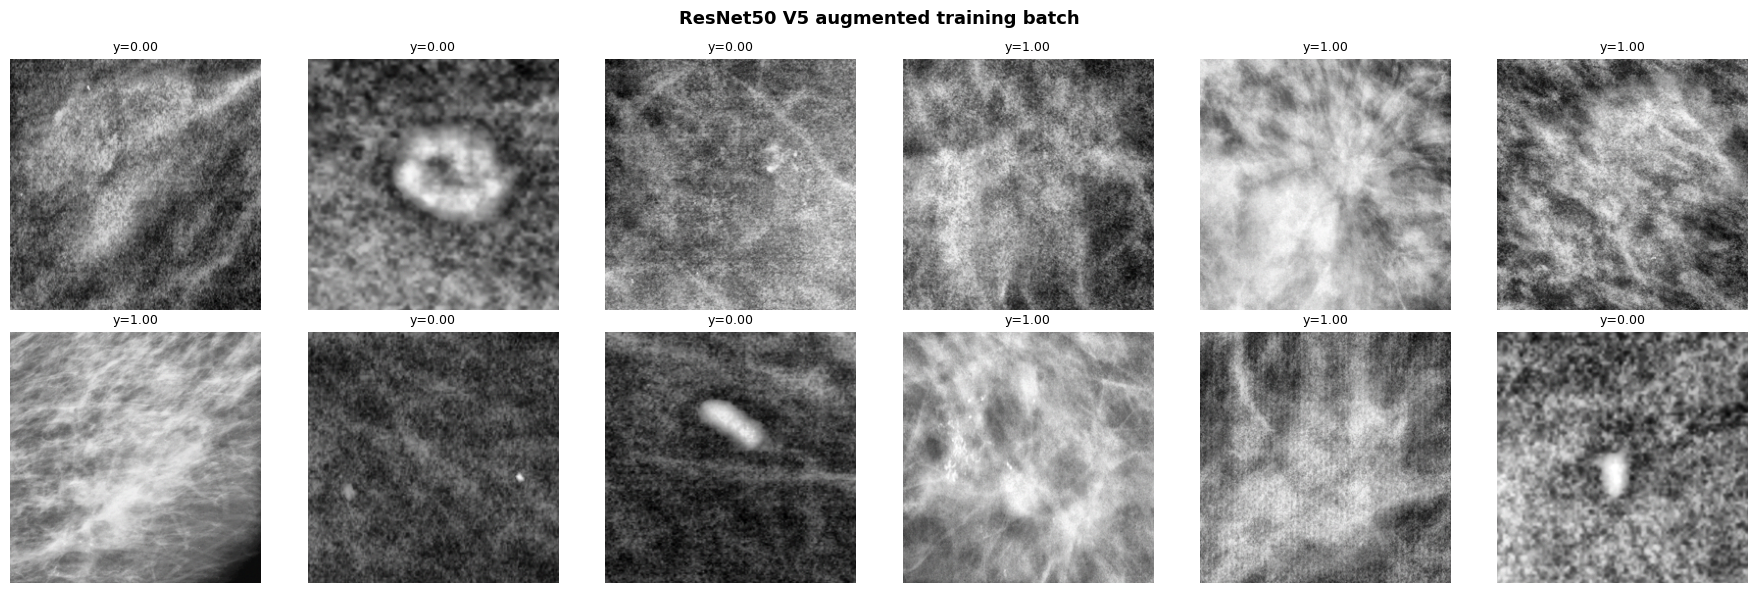

In [5]:
# ======================================================================================
# CELL 5 — Augmentation sanity check
# ======================================================================================
def deprocess_resnet(x):
    """Convert ResNet50-preprocessed BGR tensor back to displayable RGB uint8."""
    arr = x.numpy().copy()
    arr[..., 0] += 103.939
    arr[..., 1] += 116.779
    arr[..., 2] += 123.680
    arr = arr[..., ::-1]
    return np.clip(arr, 0, 255).astype(np.uint8)

batch_x, batch_y = next(iter(train_ds_mix if USE_BATCH_MIXING else train_ds_clean))
print("Batch shape :", batch_x.shape)
print("Image range :", float(tf.reduce_min(batch_x)), "to", float(tf.reduce_max(batch_x)))
print("Label range :", float(tf.reduce_min(batch_y)), "to", float(tf.reduce_max(batch_y)))

assert batch_x.shape[1:] == (IMG_SIZE, IMG_SIZE, CHANNELS), "Image shape mismatch."
assert float(tf.reduce_max(batch_x)) > 50 or float(tf.reduce_min(batch_x)) < -50, "ResNet preprocess range looks wrong."

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, ax in enumerate(axes.flat):
    if i < batch_x.shape[0]:
        ax.imshow(deprocess_resnet(batch_x[i]))
        ax.set_title(f"y={float(batch_y[i]):.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("ResNet50 V5 augmented training batch", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "augmentation_sanity.png", dpi=140, bbox_inches="tight")
plt.show()


In [6]:
# ======================================================================================
# CELL 6 — Build ResNet50 with SE attention and a ResNet-safe dual-pooling head
# ======================================================================================
def se_block(feat, ratio=8, name="se"):
    channels = int(feat.shape[-1])
    x = layers.GlobalAveragePooling2D(name=f"{name}_gap")(feat)
    x = layers.Dense(max(channels // ratio, 32), activation="relu", kernel_initializer="he_normal", name=f"{name}_fc1")(x)
    x = layers.Dense(channels, activation="sigmoid", kernel_initializer="glorot_uniform", name=f"{name}_fc2")(x)
    x = layers.Reshape((1, 1, channels), name=f"{name}_reshape")(x)
    return layers.Multiply(name=f"{name}_scale")([feat, x])

def build_resnet50_v6():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name="input")
    base = ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)
    base.trainable = False

    feat = base.output                         # conv5_block3_out
    feat = se_block(feat, ratio=8, name="se_conv5")
    feat = layers.SpatialDropout2D(0.06, name="spatial_drop")(feat)

    gap = layers.GlobalAveragePooling2D(name="gap")(feat)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(feat)
    x = layers.Concatenate(name="pool_concat")([gap, gmp])

    x = layers.BatchNormalization(name="head_bn0")(x)
    x = layers.Dropout(DROPOUT_RATE, name="head_drop0")(x)

    x = layers.Dense(512, use_bias=False, kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(L2_REG), name="head_fc1")(x)
    x = layers.BatchNormalization(name="head_bn1")(x)
    x = layers.Activation("swish", name="head_swish1")(x)
    x = layers.Dropout(0.30, name="head_drop1")(x)

    x = layers.Dense(192, use_bias=False, kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(L2_REG), name="head_fc2")(x)
    x = layers.BatchNormalization(name="head_bn2")(x)
    x = layers.Activation("swish", name="head_swish2")(x)
    x = layers.Dropout(0.20, name="head_drop2")(x)

    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(x)
    model = Model(inputs, outputs, name=MODEL_NAME)
    return model, base

model, base = build_resnet50_v6()
HEAD_LAYER_PREFIXES = ("se_conv5", "spatial_drop", "gap", "gmp", "pool_concat", "head_", "output")

print(f"Total params     : {model.count_params():,}")
print(f"Trainable params : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 26,853,441
Trainable params : 3,256,129


Model: "ResNet50_ULTRA_V6_PATIENT_SAFE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 26,853,441 (102.44 MB)

 Trainable params: 3,256,129 (12.42 MB)

 Non-trainable params: 23,597,312 (90.02 MB)

In [7]:
# ======================================================================================
# CELL 7 — Loss, LR schedule, callbacks, checkpoint utilities
# ======================================================================================
def weighted_bce_loss(label_smoothing=LABEL_SMOOTH):
    """Weighted BCE using CLASS_WEIGHTS. More stable for ResNet50 than aggressive focal by default."""
    w0 = tf.constant(CLASS_WEIGHTS[0], tf.float32)
    w1 = tf.constant(CLASS_WEIGHTS[1], tf.float32)
    ls = tf.constant(label_smoothing, tf.float32)
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        if label_smoothing > 0:
            y_true = y_true * (1.0 - ls) + 0.5 * ls
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        weights = y_true * w1 + (1.0 - y_true) * w0
        return tf.reduce_mean(weights * bce)
    return loss_fn

def focal_bce_loss(gamma=FOCAL_GAMMA, alpha=None, label_smoothing=LABEL_SMOOTH):
    if alpha is None:
        alpha = FOCAL_ALPHA
    alpha = tf.constant(float(alpha), tf.float32)
    gamma = tf.constant(float(gamma), tf.float32)
    ls = tf.constant(float(label_smoothing), tf.float32)
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        if label_smoothing > 0:
            y_true = y_true * (1.0 - ls) + 0.5 * ls
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        pt = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1.0 - pt, gamma) * bce)
    return loss_fn

def get_loss():
    return focal_bce_loss() if USE_FOCAL_LOSS else weighted_bce_loss()

class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps, min_lr=MIN_LR):
        super().__init__()
        self.peak_lr = float(peak_lr)
        self.total_steps = int(total_steps)
        self.warmup_steps = int(max(warmup_steps, 1))
        self.min_lr = float(min_lr)
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = self.peak_lr * step / float(self.warmup_steps)
        progress = tf.clip_by_value((step - self.warmup_steps) / max(float(self.total_steps - self.warmup_steps), 1.0), 0.0, 1.0)
        cosine = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (1.0 + tf.cos(math.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)
    def get_config(self):
        return {"peak_lr": self.peak_lr, "total_steps": self.total_steps, "warmup_steps": self.warmup_steps, "min_lr": self.min_lr}

def make_lr(lr, epochs):
    total_steps = max(epochs * steps_per_epoch, 1)
    warmup_steps = max(int(total_steps * WARMUP_FRAC), 1)
    return WarmupCosine(lr, total_steps, warmup_steps, MIN_LR)

def make_optimizer(lr_schedule):
    # AdamW fallback for older TF builds.
    try:
        return optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, clipnorm=CLIPNORM)
    except Exception:
        print("AdamW unavailable; using Adam fallback.")
        return optimizers.Adam(learning_rate=lr_schedule, clipnorm=CLIPNORM)

METRICS = [
    tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
    tf.keras.metrics.AUC(name="auc", curve="ROC", num_thresholds=200),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR", num_thresholds=200),
    tf.keras.metrics.Precision(name="precision", thresholds=0.5),
    tf.keras.metrics.Recall(name="recall", thresholds=0.5),
]

class TopKSnapshotter(callbacks.Callback):
    def __init__(self, folder, prefix, k=TOP_K_SNAPSHOTS, monitor="val_auc"):
        super().__init__()
        self.folder = Path(folder)
        self.folder.mkdir(parents=True, exist_ok=True)
        self.prefix = prefix
        self.k = int(k)
        self.monitor = monitor
        self.records = []
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        score = logs.get(self.monitor)
        if score is None or not np.isfinite(score):
            return
        path = self.folder / f"{self.prefix}_epoch{epoch+1:03d}_{self.monitor}{float(score):.5f}.weights.h5"
        self.model.save_weights(str(path))
        self.records.append((float(score), str(path)))
        self.records = sorted(self.records, key=lambda x: x[0], reverse=True)
        for _, old in self.records[self.k:]:
            try:
                os.remove(old)
            except OSError:
                pass
        self.records = self.records[:self.k]
    def get_paths(self):
        return [p for _, p in sorted(self.records, key=lambda x: x[0], reverse=True) if os.path.exists(p)]

def set_resnet_trainability(base_model, trainable_stages):
    """Train selected ResNet stages only; BatchNorm stays frozen for small medical datasets."""
    trainable_stages = tuple(trainable_stages)
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = any(layer.name.startswith(stage) for stage in trainable_stages)
    # Make sure custom head stays trainable.
    for layer in model.layers:
        if layer.name.startswith(HEAD_LAYER_PREFIXES):
            layer.trainable = True
    n_train = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"Trainable params now: {n_train:,}")
    print("Trainable ResNet layers:", [l.name for l in base_model.layers if l.trainable][-16:])
def compile_model(lr, epochs):
    model.compile(
        optimizer=make_optimizer(make_lr(lr, epochs)),
        loss=get_loss(),
        metrics=METRICS,
    )

def predict_probs(weight_path, ds):
    model.load_weights(weight_path)
    return model.predict(ds, verbose=0).reshape(-1)

def select_best_candidate(candidates, val_ds, y_val, tag):
    rows = []
    for name, path in candidates:
        if path and os.path.exists(path):
            p = predict_probs(path, val_ds)
            auc = roc_auc_score(y_val, p)
            rows.append({"name": name, "path": path, "val_auc": float(auc)})
            print(f"{tag:<8} {name:<22} val_auc={auc:.5f}")
    assert rows, f"No valid candidates for {tag}"
    df = pd.DataFrame(rows).sort_values("val_auc", ascending=False).reset_index(drop=True)
    df.to_csv(SAVE_DIR / f"{tag}_candidate_val_auc.csv", index=False)
    return df.iloc[0].to_dict(), df


In [8]:
# ======================================================================================
# CELL 8 — Phase 1: train classification head
# ======================================================================================
print("\n" + "=" * 80)
print("PHASE 1 — Head training, frozen ResNet50 backbone")
print("=" * 80)

base.trainable = False
for layer in model.layers:
    if layer.name.startswith(HEAD_LAYER_PREFIXES):
        layer.trainable = True

phase1_ckpt = str(SAVE_DIR / "phase1_best.weights.h5")
snap_p1 = TopKSnapshotter(SAVE_DIR / "snapshots_phase1", prefix="p1")
compile_model(PHASE1_LR, PHASE1_EPOCHS)

history_p1 = model.fit(
    train_ds_mix if USE_BATCH_MIXING else train_ds_clean,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        callbacks.ModelCheckpoint(phase1_ckpt, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / "phase1_history.csv")),
        callbacks.TerminateOnNaN(),
        snap_p1,
    ],
    verbose=1,
)
print(f"Phase 1 best val_AUC = {max(history_p1.history.get('val_auc', [0])):.5f}")



PHASE 1 — Head training, frozen ResNet50 backbone
Epoch 1/18
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.5480 - auc: 0.6061 - loss: 0.7295 - pr_auc: 0.5059 - precision: 0.4656 - recall: 0.6606
Epoch 1: val_auc improved from None to 0.71998, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6/phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6/phase1_best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 78s 491ms/step - accuracy: 0.5816 - auc: 0.6507 - loss: 0.7015 - pr_auc: 0.5551 - precision: 0.4928 - recall: 0.6938 - val_accuracy: 0.6581 - val_auc: 0.7200 - val_loss: 0.6417 - val_pr_auc: 0.6105 - val_precision: 0.5528 - val_recall: 0.6869
Epoch 2/18
104/105 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6189 - auc: 0.7115 - loss: 0.6461 - pr_auc: 0.6067 - precision: 0.5133 - recall: 0.6864
Epoch 2: val_auc improved from 0.71998 to 0.74943, saving m

In [9]:
# ======================================================================================
# CELL 9 — Phase 2: fine-tune ResNet conv5_x
# ======================================================================================
print("\n" + "=" * 80)
print("PHASE 2 — Fine-tune ResNet conv5_x")
print("=" * 80)

model.load_weights(phase1_ckpt)
set_resnet_trainability(base, trainable_stages=["conv5_"])

phase2_ckpt = str(SAVE_DIR / "phase2_best.weights.h5")
snap_p2 = TopKSnapshotter(SAVE_DIR / "snapshots_phase2", prefix="p2")
compile_model(PHASE2_LR, PHASE2_EPOCHS)

history_p2 = model.fit(
    train_ds_clean,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        callbacks.ModelCheckpoint(phase2_ckpt, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=12, restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / "phase2_history.csv")),
        callbacks.TerminateOnNaN(),
        snap_p2,
    ],
    verbose=1,
)
print(f"Phase 2 best val_AUC = {max(history_p2.history.get('val_auc', [0])):.5f}")

# Select best so far by clean validation AUC.
y_val = val_df["label"].astype(int).values
p1_paths = [("phase1_best", phase1_ckpt)] + [(f"p1_snapshot_{i+1}", p) for i, p in enumerate(snap_p1.get_paths())]
p2_paths = [("phase2_best", phase2_ckpt)] + [(f"p2_snapshot_{i+1}", p) for i, p in enumerate(snap_p2.get_paths())]
best_p2, p2_df = select_best_candidate(p1_paths + p2_paths, val_ds, y_val, tag="phase2")
selected_p2_path = str(SAVE_DIR / "phase2_selected_best.weights.h5")
model.load_weights(best_p2["path"])
model.save_weights(selected_p2_path)
print("Selected after Phase 2:", best_p2)



PHASE 2 — Fine-tune ResNet conv5_x
Trainable params now: 18,209,601
Trainable ResNet layers: ['conv5_block1_add', 'conv5_block1_out', 'conv5_block2_1_conv', 'conv5_block2_1_relu', 'conv5_block2_2_conv', 'conv5_block2_2_relu', 'conv5_block2_3_conv', 'conv5_block2_add', 'conv5_block2_out', 'conv5_block3_1_conv', 'conv5_block3_1_relu', 'conv5_block3_2_conv', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_add', 'conv5_block3_out']
Epoch 1/45
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7244 - auc: 0.8109 - loss: 0.5306 - pr_auc: 0.7382 - precision: 0.6336 - recall: 0.7531
Epoch 1: val_auc improved from None to 0.81331, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6/phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6/phase2_best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 59s 292ms/step - accuracy: 0.7262 - auc: 0.8098 - loss: 0.5365 

In [10]:
# ======================================================================================
# CELL 10 — Phase 3: polish conv4_x + conv5_x at tiny LR
# ======================================================================================
print("\n" + "=" * 80)
print("PHASE 3 — Tiny-LR polish on ResNet conv4_x + conv5_x")
print("=" * 80)

model.load_weights(selected_p2_path)
set_resnet_trainability(base, trainable_stages=["conv4_", "conv5_"])

phase3_ckpt = str(SAVE_DIR / "phase3_best.weights.h5")
snap_p3 = TopKSnapshotter(SAVE_DIR / "snapshots_phase3", prefix="p3")
compile_model(PHASE3_LR, PHASE3_EPOCHS)

history_p3 = model.fit(
    train_ds_clean,
    epochs=PHASE3_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        callbacks.ModelCheckpoint(phase3_ckpt, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=10, restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / "phase3_history.csv")),
        callbacks.TerminateOnNaN(),
        snap_p3,
    ],
    verbose=1,
)
print(f"Phase 3 best val_AUC = {max(history_p3.history.get('val_auc', [0])):.5f}")

candidate_pool = [
    ("phase1_best", phase1_ckpt),
    ("phase2_best", phase2_ckpt),
    ("phase2_selected", selected_p2_path),
    ("phase3_best", phase3_ckpt),
]
candidate_pool += [(f"p1_snapshot_{i+1}", p) for i, p in enumerate(snap_p1.get_paths())]
candidate_pool += [(f"p2_snapshot_{i+1}", p) for i, p in enumerate(snap_p2.get_paths())]
candidate_pool += [(f"p3_snapshot_{i+1}", p) for i, p in enumerate(snap_p3.get_paths())]

best_final, candidate_df = select_best_candidate(candidate_pool, val_ds, y_val, tag="final")
final_single_path = str(SAVE_DIR / "final_single_best.weights.h5")
model.load_weights(best_final["path"])
model.save_weights(final_single_path)
model.save(str(SAVE_DIR / "resnet50_ultra_v6_final_single.keras"))
print("Final selected single checkpoint:", best_final)



PHASE 3 — Tiny-LR polish on ResNet conv4_x + conv5_x
Trainable params now: 25,297,729
Trainable ResNet layers: ['conv5_block1_add', 'conv5_block1_out', 'conv5_block2_1_conv', 'conv5_block2_1_relu', 'conv5_block2_2_conv', 'conv5_block2_2_relu', 'conv5_block2_3_conv', 'conv5_block2_add', 'conv5_block2_out', 'conv5_block3_1_conv', 'conv5_block3_1_relu', 'conv5_block3_2_conv', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_add', 'conv5_block3_out']
Epoch 1/28
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7783 - auc: 0.8503 - loss: 0.4366 - pr_auc: 0.7903 - precision: 0.7123 - recall: 0.7632
Epoch 1: val_auc improved from None to 0.82591, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6/phase3_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6/phase3_best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 77s 350ms/step - accuracy: 0.7897 - auc: 0.86

In [11]:
# ======================================================================================
# CELL 11 — Candidate probability ensemble + deterministic TTA
# ======================================================================================
print("\n" + "=" * 80)
print("FINAL CANDIDATE SELECTION + TTA")
print("=" * 80)

y_val = val_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

# Clean validation candidate ranking.
clean_rows = []
val_probs_by_name = {}
for name, path in candidate_pool + [("final_single", final_single_path)]:
    if path is None or not os.path.exists(path):
        continue
    p = predict_probs(path, val_ds)
    auc = roc_auc_score(y_val, p)
    clean_rows.append({"name": name, "path": path, "clean_val_auc": float(auc)})
    val_probs_by_name[name] = p
    print(f"{name:<22} clean val_auc={auc:.5f}")

clean_df = pd.DataFrame(clean_rows).drop_duplicates(subset=["path"]).sort_values("clean_val_auc", ascending=False).reset_index(drop=True)
clean_df.to_csv(SAVE_DIR / "all_candidate_clean_val_auc.csv", index=False)

best_single_name = clean_df.loc[0, "name"]
best_single_path = clean_df.loc[0, "path"]
best_single_auc  = float(clean_df.loc[0, "clean_val_auc"])

# Top-N probability ensemble. Use only if validation AUC improves.
topn = clean_df.head(min(3, len(clean_df)))
topn_names = topn["name"].tolist()
topn_paths = topn["path"].tolist()
ens_val_clean = np.mean([val_probs_by_name[n] for n in topn_names], axis=0)
ens_clean_auc = roc_auc_score(y_val, ens_val_clean)

print("\nClean validation comparison")
print(f"Best single : {best_single_name} AUC={best_single_auc:.5f}")
print(f"Top ensemble: {topn_names} AUC={ens_clean_auc:.5f}")

USE_ENSEMBLE = ens_clean_auc >= best_single_auc + 0.001
if USE_ENSEMBLE:
    final_weight_paths = topn_paths
    print("→ Using validation-improving top checkpoint probability ensemble.")
else:
    final_weight_paths = [best_single_path]
    print("→ Using best single checkpoint; ensemble did not improve validation AUC enough.")

def tta_predict_weight_files(weight_paths, static_ds, n_tta=TTA_STEPS, name="set"):
    per_model_probs = []
    n_tta = min(int(n_tta), 8)
    for wi, wpath in enumerate(weight_paths, start=1):
        print(f"\nWeights {wi}/{len(weight_paths)}: {Path(wpath).name}")
        model.load_weights(wpath)
        view_probs = []
        for t in range(n_tta):
            ds_tta = make_tta_ds(static_ds, t)
            p = model.predict(ds_tta, verbose=0).reshape(-1)
            view_probs.append(p)
            print(f"  {name} TTA {t+1}/{n_tta}: mean={p.mean():.5f}")
        per_model_probs.append(np.mean(view_probs, axis=0))
    return np.mean(per_model_probs, axis=0)

print("\nPredicting validation with final TTA setup...")
val_prob = tta_predict_weight_files(final_weight_paths, val_static, n_tta=TTA_STEPS, name="val")

print("\nPredicting test with final TTA setup...")
test_prob = tta_predict_weight_files(final_weight_paths, test_static, n_tta=TTA_STEPS, name="test")

print(f"\nVal TTA AUC : {roc_auc_score(y_val, val_prob):.5f}")
print(f"Test prob range: [{test_prob.min():.5f}, {test_prob.max():.5f}], mean={test_prob.mean():.5f}")



FINAL CANDIDATE SELECTION + TTA
phase1_best            clean val_auc=0.80929
phase2_best            clean val_auc=0.82229
phase2_selected        clean val_auc=0.82229
phase3_best            clean val_auc=0.82676
p1_snapshot_1          clean val_auc=0.80929
p1_snapshot_2          clean val_auc=0.80691
p1_snapshot_3          clean val_auc=0.80578
p1_snapshot_4          clean val_auc=0.80104
p2_snapshot_1          clean val_auc=0.82229
p2_snapshot_2          clean val_auc=0.81643
p2_snapshot_3          clean val_auc=0.81330
p2_snapshot_4          clean val_auc=0.80894
p3_snapshot_1          clean val_auc=0.82676
p3_snapshot_2          clean val_auc=0.82610
p3_snapshot_3          clean val_auc=0.82469
p3_snapshot_4          clean val_auc=0.82025
final_single           clean val_auc=0.82676

Clean validation comparison
Best single : phase3_best AUC=0.82676
Top ensemble: ['phase3_best', 'final_single', 'p3_snapshot_1'] AUC=0.82676
→ Using best single checkpoint; ensemble did not improve val

In [12]:
# ======================================================================================
# CELL 12 — Validation-only threshold tuning + final test evaluation
# ======================================================================================
def metric_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    npv = tn / max(tn + fn, 1)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_pred)) > 1 else 0.0
    return {
        "thr": float(thr), "acc": float(acc), "bal_acc": float(bal),
        "sensitivity": float(sens), "specificity": float(spec),
        "precision": float(prec), "recall": float(rec), "npv": float(npv),
        "f1": float(f1), "mcc": float(mcc),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }

def build_threshold_table(y_true, y_prob):
    grid = np.linspace(0.05, 0.95, 181)
    rows = [metric_at_threshold(y_true, y_prob, t) for t in grid]
    df = pd.DataFrame(rows)
    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    finite = np.isfinite(thr_roc)
    youden_thr = float(thr_roc[finite][np.argmax((tpr - fpr)[finite])]) if finite.any() else 0.5
    best_bal = float(df.loc[df["bal_acc"].idxmax(), "thr"])
    best_f1  = float(df.loc[df["f1"].idxmax(), "thr"])
    best_mcc = float(df.loc[df["mcc"].idxmax(), "thr"])
    robust_thr = float(np.median([best_bal, best_mcc, youden_thr]))
    robust_thr = float(np.clip(robust_thr, 0.05, 0.95))
    return df, {
        "thr_0.50": 0.50,
        "thr_bal_acc": best_bal,
        "thr_f1": best_f1,
        "thr_mcc": best_mcc,
        "thr_youden": youden_thr,
        "thr_robust": robust_thr,
    }

thr_df, thresholds = build_threshold_table(y_val, val_prob)
thr_df.to_csv(SAVE_DIR / "validation_threshold_search.csv", index=False)

print("\nValidation thresholds")
for k, v in thresholds.items():
    print(f"{k:<14}: {v:.5f}")

OPT_THR = thresholds["thr_robust"]
print(f"\n→ Selected robust validation threshold: {OPT_THR:.5f}")

auc_roc = roc_auc_score(y_test, test_prob)
pr_auc = average_precision_score(y_test, test_prob)
metrics_050 = metric_at_threshold(y_test, test_prob, 0.50)
metrics_opt = metric_at_threshold(y_test, test_prob, OPT_THR)

def print_metric_block(title, m):
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Acc={m['acc']:.4f} | BalAcc={m['bal_acc']:.4f} | F1={m['f1']:.4f} | MCC={m['mcc']:.4f}")
    print(f"Sens={m['sensitivity']:.4f} | Spec={m['specificity']:.4f} | Prec={m['precision']:.4f} | NPV={m['npv']:.4f}")
    print(f"TP={m['tp']} TN={m['tn']} FP={m['fp']} FN={m['fn']}")

print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)
print(f"ROC-AUC : {auc_roc:.5f}")
print(f"PR-AUC  : {pr_auc:.5f}")
print_metric_block("Threshold = 0.50", metrics_050)
print_metric_block(f"Threshold = {OPT_THR:.5f} (validation robust)", metrics_opt)

y_pred_opt = (test_prob >= OPT_THR).astype(int)
print("\nClassification report")
print(classification_report(y_test, y_pred_opt, target_names=["benign", "malignant"], digits=4, zero_division=0))

pred_df = pd.DataFrame({
    "path": test_df["path"].values,
    "true_label": y_test,
    "prob_malignant": test_prob,
    "pred_label": y_pred_opt,
})
pred_df.to_csv(SAVE_DIR / "test_predictions_tta.csv", index=False)

summary = {
    "model": MODEL_NAME,
    "img_size": IMG_SIZE,
    "resize_size": RESIZE_SIZE,
    "batch_size": BATCH_SIZE,
    "train_count": len(train_df),
    "val_count": len(val_df),
    "test_count": len(test_df),
    "loss": "focal_bce" if USE_FOCAL_LOSS else "weighted_bce",
    "tta_steps": TTA_STEPS,
    "used_ensemble": bool(USE_ENSEMBLE),
    "ensemble_members": "|".join([Path(p).name for p in final_weight_paths]),
    "opt_threshold": float(OPT_THR),
    "auc_roc": float(auc_roc),
    "pr_auc": float(pr_auc),
    **{f"test_{k}": v for k, v in metrics_opt.items()},
}
pd.DataFrame([summary]).to_csv(SAVE_DIR / "results_summary.csv", index=False)

print(f"\nSaved results to: {SAVE_DIR}")


# Aliases used by dashboard and XAI cells
y_true = y_test
y_prob = test_prob
auc_roc = float(auc_roc)
ap = float(pr_auc)
OPTIMAL_THRESHOLD = float(OPT_THR)



Validation thresholds
thr_0.50      : 0.50000
thr_bal_acc   : 0.62500
thr_f1        : 0.49000
thr_mcc       : 0.77500
thr_youden    : 0.62522
thr_robust    : 0.62522

→ Selected robust validation threshold: 0.62522

FINAL TEST RESULTS
ROC-AUC : 0.78573
PR-AUC  : 0.73616

Threshold = 0.50
----------------
Acc=0.6767 | BalAcc=0.7017 | F1=0.6862 | MCC=0.4085
Sens=0.8500 | Spec=0.5534 | Prec=0.5754 | NPV=0.8382
TP=187 TN=171 FP=138 FN=33

Threshold = 0.62522 (validation robust)
---------------------------------------
Acc=0.6824 | BalAcc=0.6915 | F1=0.6613 | MCC=0.3779
Sens=0.7455 | Spec=0.6375 | Prec=0.5942 | NPV=0.7787
TP=164 TN=197 FP=112 FN=56

Classification report
              precision    recall  f1-score   support

      benign     0.7787    0.6375    0.7011       309
   malignant     0.5942    0.7455    0.6613       220

    accuracy                         0.6824       529
   macro avg     0.6864    0.6915    0.6812       529
weighted avg     0.7019    0.6824    0.6845       529

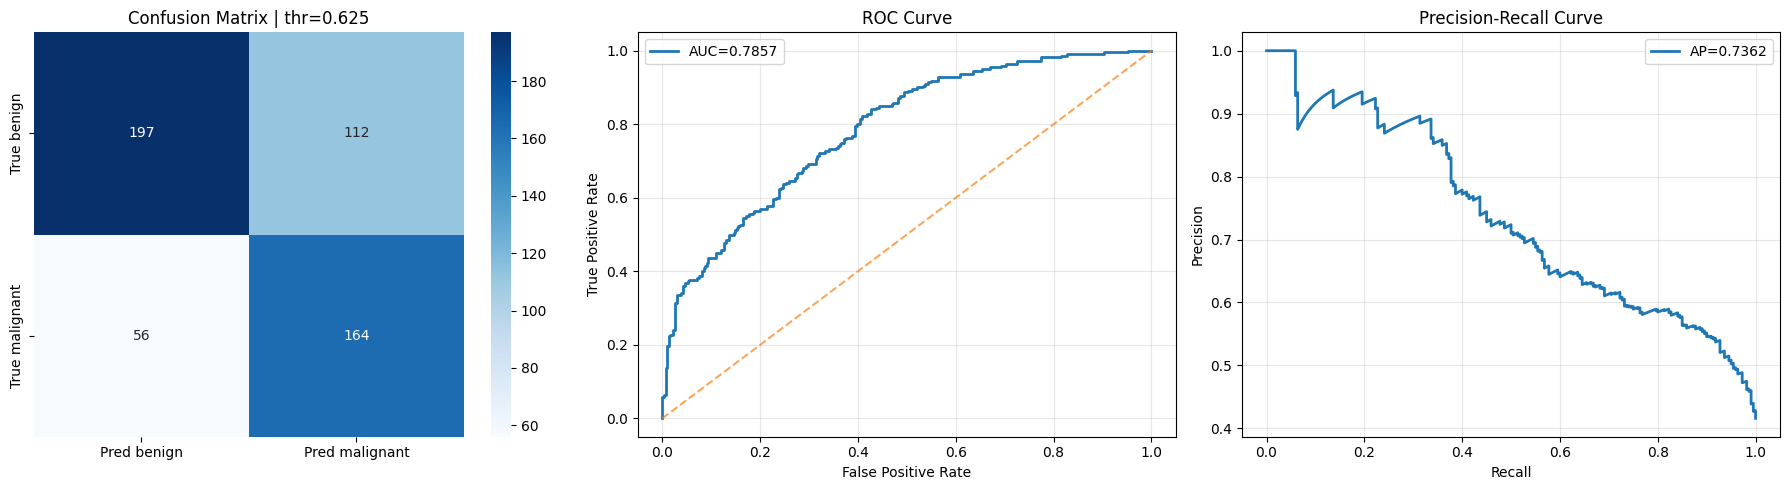

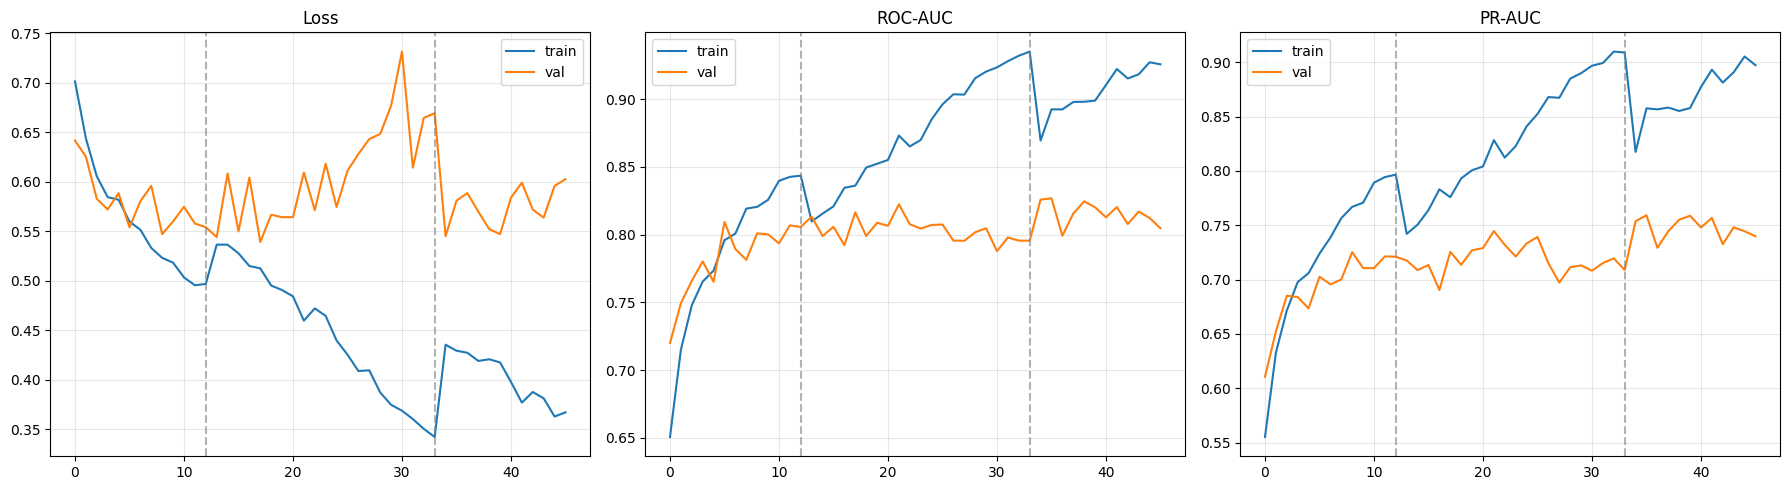

✅ ResNet50_ULTRA_V6_PATIENT_SAFE complete.
ROC-AUC=0.78573 | PR-AUC=0.73616 | F1=0.66129
Sensitivity=0.74545 | Specificity=0.63754
Important check: patient leakage audit above must show zero patient overlap.


In [13]:
# ======================================================================================
# CELL 13 — Plots and final dashboard
# ======================================================================================
fpr, tpr, _ = roc_curve(y_test, test_prob)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_prob)
cm = confusion_matrix(y_test, y_pred_opt, labels=[0, 1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred benign", "Pred malignant"],
            yticklabels=["True benign", "True malignant"])
axes[0].set_title(f"Confusion Matrix | thr={OPT_THR:.3f}")

axes[1].plot(fpr, tpr, lw=2, label=f"AUC={auc_roc:.4f}")
axes[1].plot([0, 1], [0, 1], "--", alpha=0.7)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(rec_curve, prec_curve, lw=2, label=f"AP={pr_auc:.4f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / "final_eval_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Training curve plot.
def get_hist(h, key):
    return list(h.history.get(key, []))

all_hist = {
    "loss": get_hist(history_p1, "loss") + get_hist(history_p2, "loss") + get_hist(history_p3, "loss"),
    "val_loss": get_hist(history_p1, "val_loss") + get_hist(history_p2, "val_loss") + get_hist(history_p3, "val_loss"),
    "auc": get_hist(history_p1, "auc") + get_hist(history_p2, "auc") + get_hist(history_p3, "auc"),
    "val_auc": get_hist(history_p1, "val_auc") + get_hist(history_p2, "val_auc") + get_hist(history_p3, "val_auc"),
    "pr_auc": get_hist(history_p1, "pr_auc") + get_hist(history_p2, "pr_auc") + get_hist(history_p3, "pr_auc"),
    "val_pr_auc": get_hist(history_p1, "val_pr_auc") + get_hist(history_p2, "val_pr_auc") + get_hist(history_p3, "val_pr_auc"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tr, va, title in [
    (axes[0], "loss", "val_loss", "Loss"),
    (axes[1], "auc", "val_auc", "ROC-AUC"),
    (axes[2], "pr_auc", "val_pr_auc", "PR-AUC"),
]:
    ax.plot(all_hist[tr], label="train")
    ax.plot(all_hist[va], label="val")
    ax.axvline(len(get_hist(history_p1, "loss")) - 1, color="gray", ls="--", alpha=0.6)
    ax.axvline(len(get_hist(history_p1, "loss")) + len(get_hist(history_p2, "loss")) - 1, color="gray", ls="--", alpha=0.6)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ ResNet50_ULTRA_V6_PATIENT_SAFE complete.")
print(f"ROC-AUC={auc_roc:.5f} | PR-AUC={pr_auc:.5f} | F1={metrics_opt['f1']:.5f}")
print(f"Sensitivity={metrics_opt['sensitivity']:.5f} | Specificity={metrics_opt['specificity']:.5f}")
print("Important check: patient leakage audit above must show zero patient overlap.")


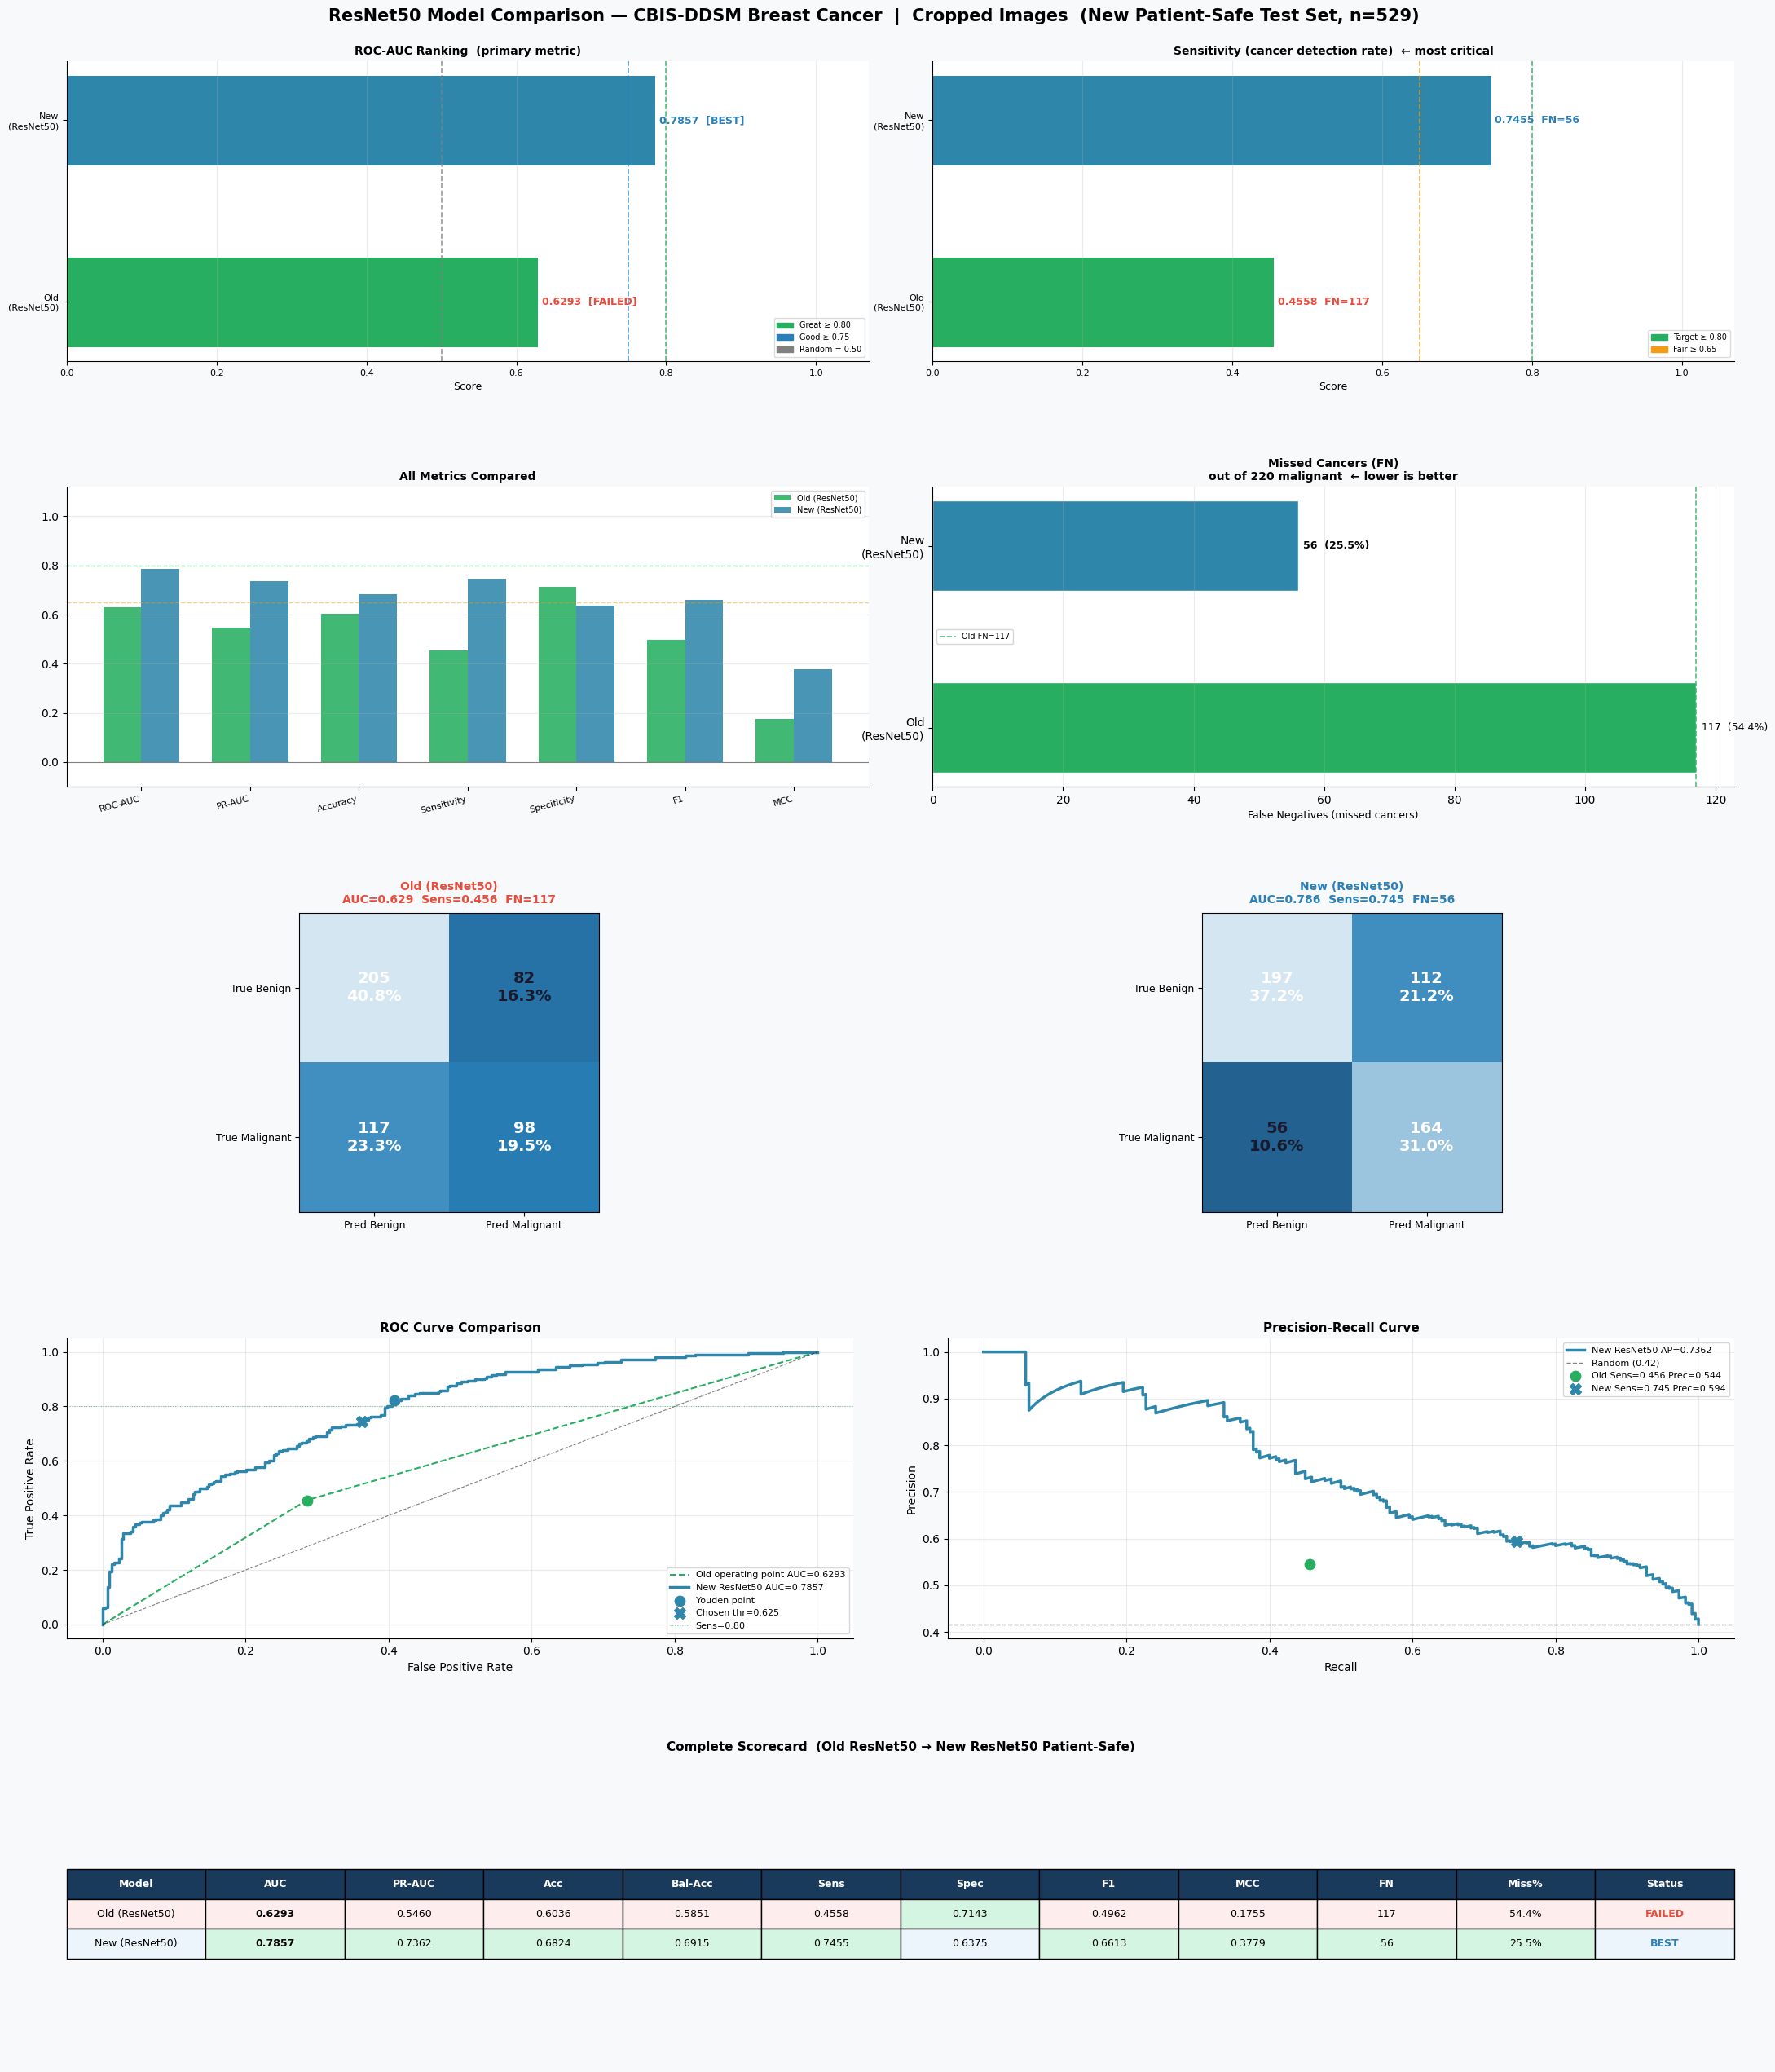

✅ ResNet50 comparison dashboard saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v6/resnet50_patient_safe_v6/resnet50_old_vs_new_comparison_dashboard.png


In [14]:
# ============================================================================
# CELL 14 - ResNet50 Old vs New Comprehensive Comparison Dashboard
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)

# ── Safety check ─────────────────────────────────────────────────────────────
_required = ["y_true", "y_prob", "SAVE_DIR"]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        "Run the ResNet50 test evaluation cells first. "
        f"Missing variables: {_missing}"
    )

if "OPTIMAL_THRESHOLD" not in globals():
    if "OPT_THR" in globals():
        OPTIMAL_THRESHOLD = float(OPT_THR)
    else:
        print("⚠️ OPTIMAL_THRESHOLD not found. Using threshold=0.50.")
        OPTIMAL_THRESHOLD = 0.50

# ── Helpers ─────────────────────────────────────────────────────────────────
def status_color(auc):
    if auc >= 0.80:
        return "#27AE60"
    if auc >= 0.75:
        return "#2980B9"
    if auc >= 0.65:
        return "#F39C12"
    return "#E74C3C"

def status_label(auc):
    if auc >= 0.80:
        return "GREAT"
    if auc >= 0.75:
        return "GOOD"
    if auc >= 0.65:
        return "FAIR"
    return "FAILED"

def clean_ax(ax, axis="both"):
    ax.grid(axis=axis, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

def safe_div(a, b):
    return 0.0 if b == 0 else a / b

# ── Current New ResNet50 metrics from live notebook arrays ───────────────────
y_true_dash = np.asarray(y_true).astype(int)
y_prob_dash = np.asarray(y_prob).astype(float)
y_pred_dash = (y_prob_dash >= float(OPTIMAL_THRESHOLD)).astype(int)

cm_new = confusion_matrix(y_true_dash, y_pred_dash, labels=[0, 1])
_tn, _fp, _fn, _tp = [int(x) for x in cm_new.ravel()]

_acc  = safe_div(_tp + _tn, _tp + _tn + _fp + _fn)
_sens = safe_div(_tp, _tp + _fn)
_spec = safe_div(_tn, _tn + _fp)
_prec = safe_div(_tp, _tp + _fp)
_f1   = f1_score(y_true_dash, y_pred_dash, zero_division=0)
_mcc  = matthews_corrcoef(y_true_dash, y_pred_dash) if len(set(y_pred_dash)) > 1 else 0.0
_bal  = balanced_accuracy_score(y_true_dash, y_pred_dash)
_auc  = roc_auc_score(y_true_dash, y_prob_dash)
_ap   = average_precision_score(y_true_dash, y_prob_dash)

# ── Model registry ───────────────────────────────────────────────────────────
# Old ResNet50 values from uploaded 6-model final comparison chart:
# AUC=.6293, PR-AUC=.5460, Acc=.6036, Sens=.4558, Spec=.7143,
# F1=.4962, MCC=.1755, TN=205, FP=82, FN=117, TP=98.
_b_tp, _b_tn, _b_fp, _b_fn = 98, 205, 82, 117

MODELS = {
    "Old\n(ResNet50)": dict(
        color="#27AE60",
        auc=0.6293,
        pr_auc=0.5460,
        acc=0.6036,
        sens=0.4558,
        spec=0.7143,
        prec=_b_tp / (_b_tp + _b_fp),
        f1=0.4962,
        mcc=0.1755,
        fn=_b_fn,
        tp=_b_tp,
        tn=_b_tn,
        fp=_b_fp,
        n_mal=_b_tp + _b_fn,
        thr=None,
    ),
    "New\n(ResNet50)": dict(
        color="#2E86AB",
        auc=float(_auc),
        pr_auc=float(_ap),
        acc=float(_acc),
        sens=float(_sens),
        spec=float(_spec),
        prec=float(_prec),
        f1=float(_f1),
        mcc=float(_mcc),
        fn=int(_fn),
        tp=int(_tp),
        tn=int(_tn),
        fp=int(_fp),
        n_mal=int(_tp + _fn),
        thr=float(OPTIMAL_THRESHOLD),
    ),
}

names = list(MODELS.keys())
colors = [MODELS[n]["color"] for n in names]
best_auc_name = max(names, key=lambda n: MODELS[n]["auc"])

def display_status(nm):
    return "BEST" if nm == best_auc_name else status_label(MODELS[nm]["auc"])

n_test_total = _tp + _tn + _fp + _fn
n_malignant = _tp + _fn

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor="#F8F9FA")
fig.suptitle(
    f"ResNet50 Model Comparison — CBIS-DDSM Breast Cancer  |  Cropped Images"
    f"  (New Patient-Safe Test Set, n={n_test_total})",
    fontsize=15,
    fontweight="bold",
    y=0.99,
)

outer = gridspec.GridSpec(
    5, 1,
    figure=fig,
    hspace=0.42,
    top=0.965,
    bottom=0.02,
    left=0.05,
    right=0.98,
)

# ── ROW 0: AUC ranking | sensitivity ranking ────────────────────────────────
row0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.08)
ax_auc = fig.add_subplot(row0[0])
ax_sens = fig.add_subplot(row0[1])

rank_auc = sorted(names, key=lambda n: MODELS[n]["auc"], reverse=True)
rank_sens = sorted(names, key=lambda n: MODELS[n]["sens"], reverse=True)

for ax, metric, order, title, reflines in [
    (
        ax_auc,
        "auc",
        rank_auc,
        "ROC-AUC Ranking  (primary metric)",
        [
            (0.80, "#27AE60", "Great ≥ 0.80"),
            (0.75, "#2980B9", "Good ≥ 0.75"),
            (0.50, "gray", "Random = 0.50"),
        ],
    ),
    (
        ax_sens,
        "sens",
        rank_sens,
        "Sensitivity (cancer detection rate)  ← most critical",
        [
            (0.80, "#27AE60", "Target ≥ 0.80"),
            (0.65, "#F39C12", "Fair ≥ 0.65"),
        ],
    ),
]:
    vals = [MODELS[n][metric] for n in order]
    cols = [MODELS[n]["color"] for n in order]

    bars = ax.barh(order, vals, color=cols, height=0.5, edgecolor="white", linewidth=0.7)
    ax.invert_yaxis()

    for bar, val, nm in zip(bars, vals, order):
        sc = status_color(MODELS[nm]["auc"])
        label = (
            f"{val:.4f}  [{display_status(nm)}]"
            if metric == "auc"
            else f"{val:.4f}  FN={MODELS[nm]['fn']}"
        )
        ax.text(
            val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=9,
            color=sc,
            fontweight="bold",
        )

    for xv, c, lbl in reflines:
        ax.axvline(xv, color=c, ls="--", lw=1.2, alpha=0.8)

    ax.set_xlim(0, 1.07)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Score", fontsize=9)
    clean_ax(ax, axis="x")

    handles = [mpatches.Patch(color=c, label=lbl) for _, c, lbl in reflines]
    ax.legend(handles=handles, fontsize=7, loc="lower right", framealpha=0.7)

# ── ROW 1: all metrics | missed cancers ─────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.08)
ax_multi = fig.add_subplot(row1[0])
ax_fn = fig.add_subplot(row1[1])

MK = ["auc", "pr_auc", "acc", "sens", "spec", "f1", "mcc"]
MLBL = ["ROC-AUC", "PR-AUC", "Accuracy", "Sensitivity", "Specificity", "F1", "MCC"]

x = np.arange(len(MK))
bw = 0.35

for i, nm in enumerate(names):
    vals = [MODELS[nm][k] for k in MK]
    ax_multi.bar(
        x + (i - 0.5) * bw,
        vals,
        bw,
        color=MODELS[nm]["color"],
        alpha=0.88,
        label=nm.replace("\n", " "),
    )

all_vals = [MODELS[nm][k] for nm in names for k in MK]
ax_multi.set_xticks(x)
ax_multi.set_xticklabels(MLBL, rotation=15, ha="right", fontsize=8)
ax_multi.set_ylim(min(-0.10, min(all_vals) - 0.05), 1.12)
ax_multi.axhline(0.00, color="black", lw=0.8, alpha=0.45)
ax_multi.axhline(0.80, color="#27AE60", ls="--", lw=1, alpha=0.5)
ax_multi.axhline(0.65, color="#F39C12", ls="--", lw=1, alpha=0.5)
ax_multi.set_title("All Metrics Compared", fontsize=10, fontweight="bold")
ax_multi.legend(fontsize=7, loc="upper right")
clean_ax(ax_multi, axis="y")

rank_fn = sorted(names, key=lambda n: MODELS[n]["fn"])
fn_vals = [MODELS[n]["fn"] for n in rank_fn]
fn_cols = [MODELS[n]["color"] for n in rank_fn]

fn_bars = ax_fn.barh(rank_fn, fn_vals, color=fn_cols, height=0.5, edgecolor="white")
ax_fn.invert_yaxis()

for bar, fn, nm in zip(fn_bars, fn_vals, rank_fn):
    n_mal = MODELS[nm]["n_mal"]
    ax_fn.text(
        fn + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{fn}  ({fn / n_mal * 100:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold" if "New" in nm else "normal",
    )

ax_fn.axvline(
    _b_fn,
    color=MODELS["Old\n(ResNet50)"]["color"],
    ls="--",
    lw=1.2,
    alpha=0.8,
    label=f"Old FN={_b_fn}",
)
ax_fn.set_title(
    f"Missed Cancers (FN)\nout of {n_malignant} malignant  ← lower is better",
    fontsize=10,
    fontweight="bold",
)
ax_fn.set_xlabel("False Negatives (missed cancers)", fontsize=9)
ax_fn.legend(fontsize=7)
clean_ax(ax_fn, axis="x")

# ── ROW 2: confusion matrices ───────────────────────────────────────────────
row2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.18)
cmap_cm = LinearSegmentedColormap.from_list(
    "cm_dashboard",
    ["#1A3A5C", "#2980B9", "#D4E6F1"],
)

for i, nm in enumerate(names):
    d = MODELS[nm]
    cm_arr = np.array([[d["tn"], d["fp"]], [d["fn"], d["tp"]]])
    n = cm_arr.sum()

    ax = fig.add_subplot(row2[i])
    ax.imshow(cm_arr, cmap=cmap_cm, vmin=0, vmax=max(cm_arr.max(), 1))

    for r in range(2):
        for c in range(2):
            val = cm_arr[r, c]
            ax.text(
                c,
                r,
                f"{val}\n{val / n * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="white" if val > cm_arr.max() * 0.4 else "#1A1A2E",
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Benign", "Pred Malignant"], fontsize=9)
    ax.set_yticklabels(["True Benign", "True Malignant"], fontsize=9)
    ax.set_title(
        f"{nm.replace(chr(10), ' ')}\n"
        f"AUC={d['auc']:.3f}  Sens={d['sens']:.3f}  FN={d['fn']}",
        fontsize=10,
        fontweight="bold",
        color=status_color(d["auc"]),
        pad=8,
    )

# ── ROW 3: ROC and PR curves ────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3], wspace=0.12)
ax_roc = fig.add_subplot(row3[0])
ax_pr = fig.add_subplot(row3[1])

fpr_new, tpr_new, thr_new = roc_curve(y_true_dash, y_prob_dash)
youden_idx = int(np.argmax(tpr_new - fpr_new))

pr_precision, pr_recall, _ = precision_recall_curve(y_true_dash, y_prob_dash)
random_pr = y_true_dash.mean()

b = MODELS["Old\n(ResNet50)"]
n = MODELS["New\n(ResNet50)"]

# Old raw probabilities are not available from the image,
# so this is an operating-point proxy using the old confusion matrix.
ax_roc.plot(
    [0, 1 - b["spec"], 1],
    [0, b["sens"], 1],
    "--",
    color=b["color"],
    lw=1.5,
    label=f"Old operating point AUC={b['auc']:.4f}",
)
ax_roc.scatter(
    [1 - b["spec"]],
    [b["sens"]],
    color=b["color"],
    s=80,
    zorder=5,
)

ax_roc.plot(
    fpr_new,
    tpr_new,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"New ResNet50 AUC={n['auc']:.4f}",
)
ax_roc.scatter(
    [fpr_new[youden_idx]],
    [tpr_new[youden_idx]],
    color=n["color"],
    s=80,
    zorder=5,
    label="Youden point",
)
ax_roc.scatter(
    [1 - n["spec"]],
    [n["sens"]],
    marker="X",
    color=n["color"],
    s=100,
    zorder=6,
    label=f"Chosen thr={n['thr']:.3f}",
)

ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax_roc.axhline(0.80, color="#27AE60", ls=":", lw=0.8, alpha=0.6, label="Sens=0.80")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve Comparison", fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8)
clean_ax(ax_roc)

ax_pr.plot(
    pr_recall,
    pr_precision,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"New ResNet50 AP={n['pr_auc']:.4f}",
)
ax_pr.axhline(random_pr, color="gray", ls="--", lw=1, label=f"Random ({random_pr:.2f})")

ax_pr.scatter(
    [b["sens"]],
    [b["prec"]],
    color=b["color"],
    s=80,
    zorder=5,
    label=f"Old Sens={b['sens']:.3f} Prec={b['prec']:.3f}",
)
ax_pr.scatter(
    [n["sens"]],
    [n["prec"]],
    color=n["color"],
    marker="X",
    s=100,
    zorder=6,
    label=f"New Sens={n['sens']:.3f} Prec={n['prec']:.3f}",
)

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
ax_pr.legend(fontsize=8)
clean_ax(ax_pr)

# ── ROW 4: scorecard table ─────────────────────────────────────────────────
ax_tbl = fig.add_subplot(outer[4])
ax_tbl.axis("off")

COLS = [
    "Model",
    "AUC",
    "PR-AUC",
    "Acc",
    "Bal-Acc",
    "Sens",
    "Spec",
    "F1",
    "MCC",
    "FN",
    "Miss%",
    "Status",
]

rows_data = []
for nm in names:
    d = MODELS[nm]
    bal_acc = (d["sens"] + d["spec"]) / 2
    rows_data.append([
        nm.replace("\n", " "),
        f"{d['auc']:.4f}",
        f"{d['pr_auc']:.4f}",
        f"{d['acc']:.4f}",
        f"{bal_acc:.4f}",
        f"{d['sens']:.4f}",
        f"{d['spec']:.4f}",
        f"{d['f1']:.4f}",
        f"{d['mcc']:.4f}",
        str(d["fn"]),
        f"{d['fn'] / d['n_mal'] * 100:.1f}%",
        display_status(nm),
    ])

tbl = ax_tbl.table(cellText=rows_data, colLabels=COLS, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.2)

# Header
for j in range(len(COLS)):
    tbl[(0, j)].set_facecolor("#1A3A5C")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

row_bg = ["#FDEDEC", "#EBF5FB"]
for i, nm in enumerate(names):
    sc = status_color(MODELS[nm]["auc"])
    for j in range(len(COLS)):
        cell = tbl[(i + 1, j)]
        cell.set_facecolor(row_bg[i])
        if j == 1:
            cell.set_text_props(fontweight="bold")
        if j == len(COLS) - 1:
            cell.set_text_props(color=sc, fontweight="bold")

# Highlight winners
higher_is_better = {1, 2, 3, 4, 5, 6, 7, 8}
lower_is_better = {9, 10}

for col_idx in range(1, len(COLS) - 1):
    raw = []
    for r in range(len(names)):
        txt = tbl[(r + 1, col_idx)].get_text().get_text().replace("%", "")
        raw.append(float(txt))

    if col_idx in higher_is_better:
        best_val = max(raw)
    elif col_idx in lower_is_better:
        best_val = min(raw)
    else:
        continue

    for r, val in enumerate(raw):
        if abs(val - best_val) < 1e-9:
            tbl[(r + 1, col_idx)].set_facecolor("#D5F5E3")

ax_tbl.set_title(
    "Complete Scorecard  (Old ResNet50 → New ResNet50 Patient-Safe)",
    fontsize=11,
    fontweight="bold",
    pad=12,
    y=1.0,
)

# ── Save ────────────────────────────────────────────────────────────────────
save_path = Path(SAVE_DIR) / "resnet50_old_vs_new_comparison_dashboard.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.show()

print(f"✅ ResNet50 comparison dashboard saved → {save_path}")
